# Prepare the structures and the features for R, P, M and $\delta$ phases

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
from dependencies.bopdftprojections.bopdftprojections.projections import Projections
from Tools import PlottingTools as plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
import logging
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
target_case = 'EF_nmhcp'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

In [2]:
logger = logging.getLogger()
logging.basicConfig( format='%(message)s',level=logging.INFO,)


In [3]:
#plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('axes', labelsize=18)

In [4]:
import logging

In [5]:
logger = logging.getLogger()
logging.basicConfig(level=logging.INFO)

In [6]:
from mendeleev import element


In [7]:
DS = Dataset(dataset=dataset, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]
TRAIN_RBS = BS.query('Phase == "R"')

In [8]:
DS.StructureNames[DS.StructureNames == 'M']

Series([], Name: Phase, dtype: object)

In [9]:
train_features = DS.Features

In [10]:
train_features['atomic']['Structure'].max()

10

In [11]:
train_features['atomic']['Structure'].min()

0

In [12]:
pd.concat([ DS.StructureNames, train_features['atomic']['Structure']], axis =1 ).reset_index(drop=True).drop_duplicates().sort_values('Structure')

,Phase,Structure
180,A15,0
6,C14,1
179,C15,2
0,C36,3
1,R,4
11,chi,6
2,mu,9
3,sigma,10


Text(0, 0.5, '$\\Delta E_F$ (meV/at)')

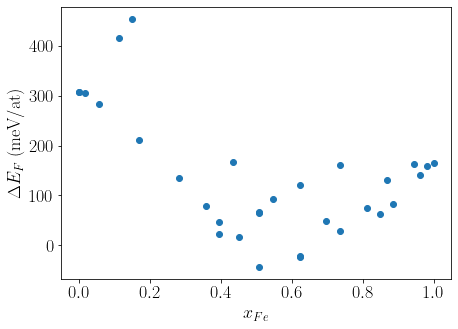

In [13]:
fig, axes = plt.subplots()
axes.scatter(TRAIN_RBS['Fe_pv'], TRAIN_RBS['EF_nmhcp']*1000)
axes.set_xlabel('$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_F$ (meV/at)')

In [14]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [15]:
LearningAtomsObjects = pd.read_pickle('Fe-Mo/Atomsobjects/Fe-Mo-POSCAR-initial-rescaled-AtomsObjects.pkl').query('index.str.contains("R-.*NM$")')

In [16]:
binaries_predict = {'R' :
#                        {'permutations': LearningAtomsObjects.index.str.split('\.').map(lambda s: s[1]),
#                         'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}
                    {'permutations': permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}, 
                    'R_old':
                    {'permutations': old_permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset, 'Atomsobjects/R_structures_old.pkl')},
                    'P' : 
                    {'permutations': permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
#                    'P_old' : 
#                    {'permutations': old_permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
                    'delta': 
                    {'permutations': permutate('delta', 2, 14), 'atoms_objects_file' : os.path.join(dataset,'Atomsobjects/delta_structures.pkl') },
                    'M':
                    {'permutations': permutate('M', 2, 11 ), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects', 'M_structures.pkl' )}
                   }

In [17]:
MAO = SourceFileLoader('MAO', 'Tools/PredictionTools/MakeAtomsOjects.py').load_module()

In [18]:
    atom_volumes = MAO.get_atom_volume_from_mp({'Fe' : 'mp-13', 'Mo' : 'mp-129'})

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
atom_volumes

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [20]:
for name, binary in binaries_predict.items():
    print(name)
    if os.path.exists(binary['atoms_objects_file']):
        binary['Atoms'] = pd.read_pickle(binary['atoms_objects_file'])
    else:
        binary['Atoms'] = make_all_atoms_objects(binary['permutations'], atom_volumes_def=atom_volumes)
        binary['Atoms'] = binary['Atoms'].to_frame()
        binary['Atoms'].index = binary['Atoms'].index +'.NM'
        binary['Atoms'].columns = ['atoms']
        binary['Atoms'].to_pickle(binary['atoms_objects_file'])
binaries_predict['R']['Atoms'].index = binaries_predict['R']['Atoms'].index.str.replace("-AAAAAAAAAAA", '')
binaries_predict['R']['Atoms'].index = binaries_predict['R']['Atoms'].index.str.replace("-BBBBBBBBBBB", '')

R
R_old
P
delta
M


## compare atoms objects to the ones used for learning

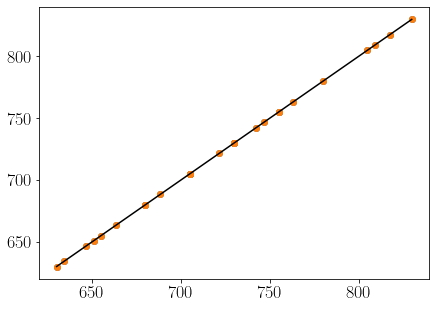

In [21]:
not_created = binaries_predict['R']['Atoms'].index.difference(LearningAtomsObjects.index)

intersection = LearningAtomsObjects.index.intersection(binaries_predict['R']['Atoms'].index)

created_intersection_volumes = binaries_predict['R']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())

alt_created_intersection_volumes = binaries_predict['R_old']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())


intersection_volumes = LearningAtomsObjects.atoms[intersection].map(lambda a: a.get_volume())

fig, axes = plt.subplots()
axes.scatter(intersection_volumes, created_intersection_volumes)
axes.scatter(intersection_volumes, alt_created_intersection_volumes)
axes.plot([ created_intersection_volumes.min(), created_intersection_volumes.max() ], [ created_intersection_volumes.min(), created_intersection_volumes.max() ], '-k')


In [22]:
theatoms=binaries_predict['P']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [23]:
theatoms=binaries_predict['R']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [24]:
theatoms=binaries_predict['delta']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [25]:
theatoms=binaries_predict['M']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

# Make BS 

In [26]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [27]:
BS_predict = {}
for name, binarypredict in binaries_predict.items():
    BS_predict[name] = binarypredict['Atoms'].atoms.map(len)
    BS_predict[name].name = 'num_atoms'
    compo = pd.DataFrame.from_dict(
        binarypredict['Atoms'].atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
        orient = 'index'
    ).fillna(0)
    compo['Fe_pv'] = compo['Fe'] / BS_predict[name]
    compo['Mo_sv'] = 1 - compo['Fe_pv']
    compo['Mag'] = 0 #NM
    compo['nelem'] = binarypredict['Atoms'].atoms.map(get_nelem)
    BS_predict[name] = pd.concat([BS_predict[name], compo], axis = 1)

In [28]:
BS_predict['R']['Structure'] = 4
BS_predict['R_old']['Structure'] = 4

In [29]:
BS_predict['P']['Structure'] = 11

In [30]:
BS_predict['delta']['Structure'] = 11

In [31]:
BS_predict['M']['Structure'] = 11

In [32]:
BS.query('Phase == "R"').columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'Mag', 'Phase', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc'],
      dtype='object')

# CALCULATE FEATURES AND APPLY CN AVERAGE. THE ATOMS OBJECTS ARE ALREADY ORDERED !

# Load BOP Features 

In [33]:
globalmoments = 16
model_definitions = {
    '0.7dprojections_0.5os': {'model_maker_options' : {
        'element_pairs_kwargs' : {
            'bond_integral_scale': 0.7,
        },
        'atom_blocks_kwargs': {
            'onsite_levels_scale' : 0.5,
            'select_orbitals' : {'Fe': 'd', 'Mo' : 'd'}
        },
    },
    'moments' : globalmoments
    },
}
cutoff = 'table'
atoms = ['initial', 'relaxed']
retry = False

In [34]:
P = Projections()
P.readbxmodels()
P.get_bond_chunks()
P.get_autobonds()
P.get_all_onsite_levels()
P.get_restructured_projections()

using merged projections


filling inverted bonds:   0%|          | 0/3868 [00:00<?, ?it/s]

In [35]:
def create_modelfile(acompound, target_model_filename, modelname='projections', element_pairs_kwargs={}, atom_blocks_kwargs={} ):
    print(acompound)
    if 'canonical' not in modelname :
        model_filename = P.save_abond_bx(acompound, return_filename=True,
                                         modelname=modelname, 
                                         element_pairs_kwargs=element_pairs_kwargs,
                                         atom_blocks_kwargs=atom_blocks_kwargs)
        print(model_filename)
    else:
        model_filename = C.base_canonical #f'models/W_canonical.bx'
    shutil.copy(model_filename, target_model_filename)

In [36]:
def replace_symbols(theatoms, replacements=None):
    new_symbols = theatoms.get_chemical_symbols()
    if replacements is not None:
        for original, replacement in replacements.items():
            new_symbols = [s.replace(original, replacement) for s in new_symbols]
    new_atoms = theatoms.copy()
    new_atoms.set_chemical_symbols(new_symbols)
    return new_atoms


In [37]:
AtomsObjects = {}
for name, binary in binaries_predict.items():
    AtomsObjects[name]  = binary['Atoms']

In [38]:
results = {}
resultspickle = {}

In [39]:
elements = dataset.split('-')

In [40]:
import shutil

In [41]:
from Tools.DatasetTools.Commoms import *
os.environ['PATH']+=':'+os.path.join(os.getcwd(),'dependencies/bopfox/src/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

In [42]:
for (model, definition), (case, atoms_df) in product(model_definitions.items(), AtomsObjects.items()):
    if 'moments' in definition.keys():
        thismoments = definition['moments']
    else:
        thismoments = 16
    if (model, thismoments, case) in results.keys():
        continue
    create_model_options = {}
    if 'model_maker_options' in definition.keys():
        create_model_options.update(definition['model_maker_options'])
    use_elements = copy.copy(elements)
    if 'replace atoms' in definition.keys():
        for realelement, targetelement in definition['replace atoms'].items():
            use_elements = set([s.replace(realelement, targetelement) for s in use_elements])
    components = ''.join(use_elements)
    modelsfile = os.path.join('models', f'{dataset}-{components}_{model}.bx')
    create_modelfile(use_elements,modelsfile, modelname=model, **create_model_options,   )
    if 'replace atoms' in definition.keys():
        ApplyOnAtoms = atoms_df['atoms'].apply(replace_symbols, replacements = definition['replace atoms'])
    else:
        ApplyOnAtoms = atoms_df.atoms
    print('atoms: ', case, 'model: ', model, '  cutoff: ', cutoff, ' moments:', thismoments)
    resultspickle[(model, thismoments, case)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{case}_{model}_{cutoff}_WUBIND_{thismoments}.pkl')
    if not os.path.exists(resultspickle[(model, thismoments, case)]):
        cwd = os.getcwd()
        BOPC = BopfoxFeatures(
            ApplyOnAtoms,modelsfile, modelname=model,
            cutoffby=cutoff, 
            binary = os.path.join(cwd, 'dependencies', 'bopfox','src', 'bopfox'),
            moments = thismoments,
            savelog=False
            )
        BOPC.featurize_dataframe(input_pickle=resultspickle, output_pickle=resultspickle, max_workers=12)
        results[(model, thismoments, case)] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) 
        results[(model, thismoments, case)].to_pickle(resultspickle[(model, thismoments, case)])
    else:
        results[(model, thismoments, case)] = pd.read_pickle(resultspickle[(model, thismoments, case)])

['Fe', 'Mo']
Fe_Mo.bx
atoms:  R model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
['Fe', 'Mo']
Fe_Mo.bx
atoms:  R_old model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
['Fe', 'Mo']
Fe_Mo.bx
atoms:  P model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
['Fe', 'Mo']
Fe_Mo.bx
atoms:  delta model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
['Fe', 'Mo']
Fe_Mo.bx
atoms:  M model:  0.7dprojections_0.5os   cutoff:  table  moments: 16


In [43]:
for (model, thismoments, case), result in results.items(): 
    if not result.index.str.contains('NM$', regex=True).all():
        result.index = result.index+'.NM'
        results[(model, thismoments, case)].to_pickle(resultspickle[(model, thismoments, case)])

In [44]:
cn_persite['R_old'] = cn_persite['R']
cn_persite['P_old'] = cn_persite['P']

In [45]:
cn_persite

{'A15': array([14, 14, 14, 14, 14, 14, 12, 12]),
 'C14': array([16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12]),
 'C15': array([16, 16, 12, 12, 12, 12]),
 'C36': array([16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12]),
 'bcc': array([14]),
 'chi': array([16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]),
 'fcc': array([12]),
 'hcp': array([12, 12]),
 'mu': array([12, 12, 12, 12, 12, 12, 12, 15, 15, 16, 16, 14, 14]),
 'sigma': array([12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 12,
        12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14, 14]),
 'R': array([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14,
        14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16,
        16, 16]),
 'delta': array([12, 12, 12, 12, 12, 12, 12, 12, 1

In [46]:
for name, struc in cn_persite.items():
    print(name, len(struc))

A15 8
C14 12
C15 6
C36 24
bcc 1
chi 29
fcc 1
hcp 2
mu 13
sigma 30
R 53
delta 56
P 56
M 52
R_old 53
P_old 56


In [47]:
for phase, list_of_atoms in AtomsObjects.items():
    print(phase, len(list_of_atoms))

R 2048
R_old 2048
P 4096
delta 16384
M 2048


In [48]:
featurescnav = {}
for name, result  in results.items():
    specialcolumns =['U_bind','U_bond_atom', 'modelsfile']#, 'U_bond_atom_list'] 
    averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[name]))

    CNList = pd.Series([cn_persite[name[-1]]]*len(result), index=result.index)

    if os.path.exists(averaged_bop_file):
        featurescnav[name] = pd.read_pickle(averaged_bop_file).astype(float)  # for some reason some values are objects
    else:
        columnstoexpand = result.columns.drop([column for column in specialcolumns if column in result.columns])
        df = gf.array_expansions(result.dropna(), columnstoexpand)
        ThisCoordination = CNList[result.index]
        print(name)
        df = gf.featurize_dataframe(df, ThisCoordination)
        shape_factors = gf.get_shape_factors(df)
        featurescnav[name] = pd.concat(
            [
                BS_predict[name[-1]][['Mag', 'Structure']].loc[df.index], 
                result[specialcolumns[:-1]].loc[df.index],
                df, shape_factors
            ],
                axis=1)
        featurescnav[name].to_pickle(averaged_bop_file)

# Load ACE features

In [49]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict as default_options_dict
from pyace import ACEBBasisSet, PyACECalculator

In [50]:
AceConfig = copy.copy(default_options_dict)

In [51]:
AceConfig['elements'] = dataset.split('-')

In [52]:
resultsace = {}

In [53]:
model = 'ACE'
description = 'lmax=321'

MyPyACECalculator = SourceFileLoader('MyPyACECalculator', 'Tools/DatasetTools/ACEDescriptors.py').load_module().MyPyACECalculator
ACEer = MyPyACECalculator(components = components, multispace_basis_config = AceConfig)
acer = MyPyACECalculator(components, multispace_basis_config=AceConfig)

for case, atoms_df in  AtomsObjects.items():
    ApplyOnAtoms = atoms_df.atoms
    print('atoms: ', case, 'model: ', 'ACE')
    resultspickle[(model, description, case)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{case}_{model}_{description}.pkl')
    print('atoms: ', case, 'model: ', 'ACE', resultspickle[(model, description, case)])
    if not os.path.exists(resultspickle[(model, description, case)]):
        cwd = os.getcwd()
        results[(model, description, case)] = acer.featurize_series(atoms_df.atoms)
        results[(model, description, case)].name = 'ace_projections'
        results[(model, description, case)]=results[(model, description, case)].to_frame()
        results[(model, description, case)].to_pickle(resultspickle[(model, description, case)])
    else:
        results[(model, description, case)] = pd.read_pickle(resultspickle[(model, description, case)])
        if isinstance(results[(model, description, case)], pd.core.series.Series):
            results[(model, description, case)] = results[(model, description, case)].to_frame()
            results[(model, description, case)].columns = ['ace_projections']

atoms:  R model:  ACE
atoms:  R model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_ACE_lmax=321.pkl
atoms:  R_old model:  ACE
atoms:  R_old model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_old_ACE_lmax=321.pkl
atoms:  P model:  ACE
atoms:  P model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_P_ACE_lmax=321.pkl
atoms:  delta model:  ACE
atoms:  delta model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_delta_ACE_lmax=321.pkl
atoms:  M model:  ACE
atoms:  M model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_M_ACE_lmax=321.pkl


In [54]:
for (model, descriptor, case), features in results.items():
#    if 'ACE' not in model:
#        continue
    print(model, descriptor, case)
    averaged_ace_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[(model, descriptor, case)]))
    columnstoexpand = features.columns
    CNList = pd.Series([cn_persite[case]]*len(features), index=features.index)
    if os.path.exists(averaged_ace_file):
        featurescnav[(model, descriptor, case)] = pd.read_pickle(averaged_ace_file)
    else:
        expanded_ace = gf.array_expansions(features, ['ace_projections'])
        featurescnav[(model, descriptor, case)] = gf.featurize_dataframe(expanded_ace, CNList)
        featurescnav[(model, descriptor, case)].to_pickle(averaged_ace_file)

0.7dprojections_0.5os 16 R
0.7dprojections_0.5os 16 R_old
0.7dprojections_0.5os 16 P
0.7dprojections_0.5os 16 delta
0.7dprojections_0.5os 16 M
ACE lmax=321 R
ACE lmax=321 R_old
ACE lmax=321 P
ACE lmax=321 delta
ACE lmax=321 M


# load SOAP

In [55]:
soapcases = ['specific']

In [56]:
from dscribe.descriptors import SOAP

from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [57]:
SOAPFEATURES = {}
EXPANDED_SOAP = {}
AVE_SOAP = {}
variances = {}
SEL_SOAP = {}
FINAL_SOAP = {}
soap_params = dict(
    r_cut = 4,
    n_max = 5,
    l_max = 4, # f
    sigma = 0.1,
    rbf = 'gto',
    periodic = True,
)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
soap_features_file={}

In [58]:
for case, atoms_df in  AtomsObjects.items():
    for soapcase in soapcases:
        if (case, soapcase) in AVE_SOAP:
          continue
        logger.info('case: %s, soap case: %s '%(case, soapcase))
        soap_features_file.update({(case,soapcase): os.path.join(dataset,'Descriptors', f'PREDICTION__prediction__{case}__{soapcase}__{params_str}.csv')})
        if os.path.exists(soap_features_file[(case, soapcase)]):
          AVE_SOAP[(case, soapcase)] = pd.read_csv(soap_features_file[(case, soapcase)], index_col = 0)
          continue
        species = [element(s).atomic_number for s in dataset.split('-')]
        thisatomsobjects = atoms_df['atoms'].map(lambda a: copy.deepcopy(a))
        SOAPER = SOAP(species=species, **soap_params)
        SOAPFEATURES.update({( case, soapcase ): thisatomsobjects.map(SOAPER.create)}) #,pd.DataFrame(data= columns=['SOAP'])
        EXPANDED_SOAP.update({( case,soapcase ): gf.array_expansions(SOAPFEATURES[( case, soapcase )].to_frame(name='SOAP'), ['SOAP'])})
        CNList = pd.Series([cn_persite[case]]*len(EXPANDED_SOAP[case+'_'+soapcase]), index=EXPANDED_SOAP[case+'_'+soapcase].index)
        AVE_SOAP.update({(case, soapcase): gf.featurize_dataframe(EXPANDED_SOAP[( case, soapcase )], CNList)})
        AVE_SOAP[( case, soapcase )].to_csv(soap_features_file[soapcase])

case: R, soap case: specific 


KeyError: 'R_specific'

In [ ]:
for case in AtomsObjects:
    for soapcase in soapcases:
        soap_features_file.update({(case,soapcase): os.path.join(dataset,'Descriptors', f'PREDICTION__{case}__{soapcase}__{params_str}.csv')})
        AVE_SOAP[( case, soapcase )].to_csv(soap_features_file[(case, soapcase)])

## update featurescnav

In [60]:
for (case, soapcase) in AVE_SOAP:
    featurescnav[('SOAP_specific_small', soapcase, case)] = AVE_SOAP[(case, soapcase)]

In [61]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 16, 'R'), ('0.7dprojections_0.5os', 16, 'R_old'), ('0.7dprojections_0.5os', 16, 'P'), ('0.7dprojections_0.5os', 16, 'delta'), ('0.7dprojections_0.5os', 16, 'M'), ('ACE', 'lmax=321', 'R'), ('ACE', 'lmax=321', 'R_old'), ('ACE', 'lmax=321', 'P'), ('ACE', 'lmax=321', 'delta'), ('ACE', 'lmax=321', 'M'), ('SOAP_specific_small', 'specific', 'R'), ('SOAP_specific_small', 'specific', 'R_old'), ('SOAP_specific_small', 'specific', 'P'), ('SOAP_specific_small', 'specific', 'delta'), ('SOAP_specific_small', 'specific', 'M')])

In [62]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Mag'], featurescnav[key] ], axis=1)
    if 'Structure' not in featurecnav.columns: 
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Structure'], featurescnav[key] ], axis = 1)

('0.7dprojections_0.5os', 16, 'R')
('0.7dprojections_0.5os', 16, 'R_old')
('0.7dprojections_0.5os', 16, 'P')
('0.7dprojections_0.5os', 16, 'delta')
('0.7dprojections_0.5os', 16, 'M')
('ACE', 'lmax=321', 'R')
('ACE', 'lmax=321', 'R_old')
('ACE', 'lmax=321', 'P')
('ACE', 'lmax=321', 'delta')
('ACE', 'lmax=321', 'M')
('SOAP_specific_small', 'specific', 'R')
('SOAP_specific_small', 'specific', 'R_old')
('SOAP_specific_small', 'specific', 'P')
('SOAP_specific_small', 'specific', 'delta')
('SOAP_specific_small', 'specific', 'M')


In [63]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        print('Mag no')
    else:
        print('Mag yea')
    if 'Structure' not in featurecnav.columns: 
        print('Structure no')
    else:
        print('Structure yea')

('0.7dprojections_0.5os', 16, 'R')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'R_old')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'P')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'delta')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'M')
Mag yea
Structure yea
('ACE', 'lmax=321', 'R')
Mag yea
Structure yea
('ACE', 'lmax=321', 'R_old')
Mag yea
Structure yea
('ACE', 'lmax=321', 'P')
Mag yea
Structure yea
('ACE', 'lmax=321', 'delta')
Mag yea
Structure yea
('ACE', 'lmax=321', 'M')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'R')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'R_old')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'P')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'delta')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'M')
Mag yea
Structure yea


# LOAD MODELS 

In [64]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [65]:
from Tools.DatasetTools.MLConveniences import filter_features

In [66]:
voting_regressor = joblib.load(regressor_file)

# Prediction ! 

In [67]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small')])

In [68]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small')])

In [69]:
ModelName = 'Kernel Ridge'
featurenames = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP_specific_small' }

In [70]:
Prediction_Values = {}
bag_of_predictions = {}
ERR = {}
for (modelkey, modelparam, phase), featurecnav in featurescnav.items():
    logger.info("%s, %s, %s, %s" %(  modelkey, modelparam, phase, featurenames[modelkey] ))
    prediction_values_location = os.path.join(dataset,'results',f'PREDICTION_{phase}_{modelkey}_{modelparam}.csv')
    combi = (ModelName, featurenames[modelkey])
    Prediction_Values[modelkey, phase] = pd.Series(voting_regressor[combi].predict(featurecnav), index=featurecnav.index, name=f'{target_case}__{modelkey}').to_frame()
    bag_of_predictions[combi] = []
    for i, (name, estimator) in enumerate(voting_regressor[combi].named_estimators_.items()):
#        this_prediction = pd.Series(estimator.predict(featurecnav), index = featurecnav.index)
#        bag_of_predictions[combi].append(this_prediction)
        Prediction_Values[modelkey, phase][f'vote_{i}']  =pd.Series(estimator.predict(featurecnav), index = featurecnav.index)
#    bag_of_predictions[combi] = pd.DataFrame(bag_of_predictions[combi]).transpose()
    Prediction_Values[modelkey, phase]['std_votes'] = Prediction_Values[modelkey, phase].filter(regex='vote_[0-9]+').std(axis=1)#bag_of_predictions[combi].std(axis=1)
    Prediction_Values[modelkey, phase].to_csv(prediction_values_location)

0.7dprojections_0.5os, 16, R, 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os, 16, R_old, 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os, 16, P, 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os, 16, delta, 0.7dProjections 0.5OS BOP
0.7dprojections_0.5os, 16, M, 0.7dProjections 0.5OS BOP
ACE, lmax=321, R, ACE
ACE, lmax=321, R_old, ACE
ACE, lmax=321, P, ACE
ACE, lmax=321, delta, ACE
ACE, lmax=321, M, ACE
SOAP_specific_small, specific, R, SOAP_specific_small
SOAP_specific_small, specific, R_old, SOAP_specific_small
SOAP_specific_small, specific, P, SOAP_specific_small
SOAP_specific_small, specific, delta, SOAP_specific_small
SOAP_specific_small, specific, M, SOAP_specific_small


In [71]:
Prediction_Values[modelkey, phase].columns

Index(['EF_nmhcp__SOAP_specific_small', 'vote_0', 'vote_1', 'vote_2', 'vote_3',
       'vote_4', 'vote_5', 'vote_6', 'vote_7', 'vote_8', 'std_votes'],
      dtype='object')

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

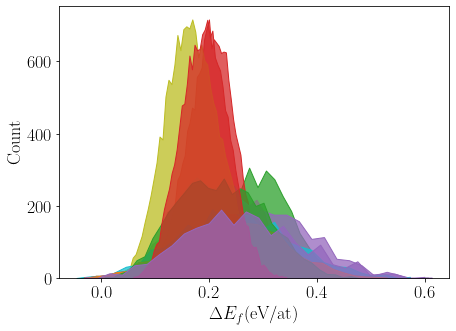

In [72]:
fig, axes = plt.subplots()
for key, serie in Prediction_Values.items():
    sns.histplot(Prediction_Values[key][f'{target_case}__{key[0]}'], element='poly', ax = axes)
axes.set_xlabel(r'$\Delta E_f $(eV/at)')

In [73]:
select_model = '0.7dprojections_0.5os'

In [74]:
coincidence = Prediction_Values[(select_model, 'R')][f'{target_case}__{select_model}'].index.intersection(TRAIN_RBS.index)

In [75]:
difference =TRAIN_RBS.index.difference(coincidence)

In [76]:
TRAIN_RBS.loc[difference]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,1,52,53,0.018868,0.981132,NM,R,0.307309,0.305966,0.304474
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076915,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,52,1,53,0.981132,0.018868,NM,R,0.228834,0.159020,0.081452
Mo_sv53.R.FM,bulk R.FM,16.315255 A,-10.625316,238.811481 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,53,0,53,0.000000,1.000000,FM,R,0.307439,0.307439,0.307439


Text(0.5, 0.01, '$x_{Fe}$')

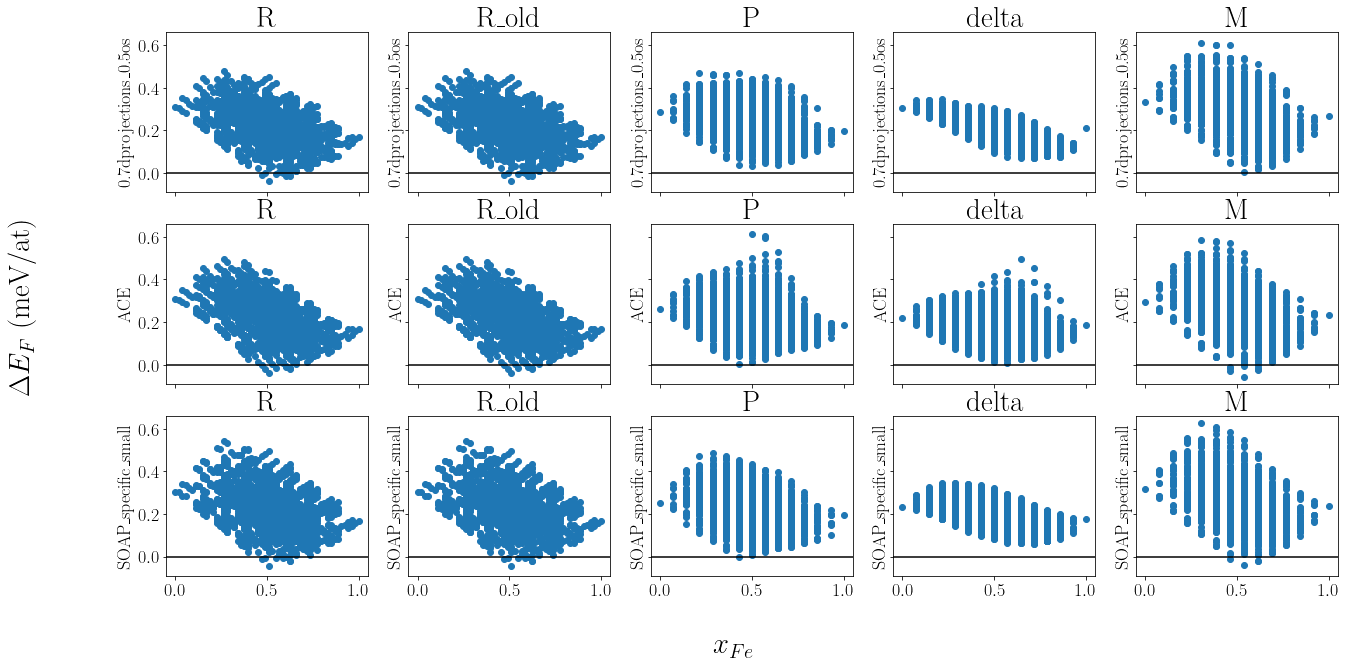

In [77]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
phase_pos = {'R': 0, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
fig, axes = plt.subplots(
    len(featurenames), len(BS_predict),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]*2),
    sharey=True, sharex=True)
for (featurename, phase), prediction  in Prediction_Values.items():
    I = featurename_pos[featurename]
    J = phase_pos[phase]
    intersection = BS_predict[phase]['Fe_pv'].index.intersection(prediction[f'{target_case}__{featurename}'].index)
    axes[I, J].scatter(
        BS_predict[phase]['Fe_pv'][intersection],
        prediction[f'{target_case}__{featurename}'][intersection],
    )
    axes[I,J].set_title(phase)
    axes[I,J].set_ylabel(featurename)
    axes[I,J].axhline(c='k')
fig.supylabel(r'$\Delta E_F$ (meV/at)')
fig.supxlabel(r'$x_{Fe}$')

In [78]:
BS_predict['R'].keys()

Index(['num_atoms', 'Fe', 'Mo', 'Fe_pv', 'Mo_sv', 'Mag', 'nelem', 'Structure'], dtype='object')

In [79]:
target_case

'EF_nmhcp'

In [80]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'R_old'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'R_old'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'R_old'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

In [81]:
Prediction_Values[('0.7dprojections_0.5os', 'R')]

,EF_nmhcp__0.7dprojections_0.5os,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,std_votes
Fe_pv53.R.NM,0.166273,0.167032,0.165502,0.166446,0.166823,0.165625,0.165545,0.165895,0.166518,0.167362,0.165899,0.166351,0.000631
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.081048,0.081868,0.081675,0.078409,0.078422,0.082262,0.078349,0.082617,0.082682,0.085248,0.078816,0.081181,0.002268
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.139748,0.137387,0.143941,0.137434,0.140969,0.140448,0.138156,0.139386,0.138272,0.139749,0.141081,0.140405,0.001938
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.064689,0.066806,0.062047,0.067128,0.067287,0.054420,0.063733,0.065143,0.065754,0.068591,0.065161,0.065506,0.003847
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.136102,0.136372,0.137616,0.127069,0.123124,0.119723,0.113296,0.149097,0.130682,0.166817,0.152570,0.140754,0.015733
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,0.343708,0.377331,0.343902,0.310720,0.361461,0.426454,0.214554,0.340411,0.345120,0.366881,0.352058,0.341894,0.051657
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,0.446353,0.452152,0.437276,0.433769,0.447942,0.444766,0.451486,0.452435,0.450845,0.449300,0.449623,0.440285,0.006474
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,0.350884,0.339938,0.357791,0.344614,0.355052,0.350795,0.359558,0.350193,0.353348,0.353591,0.350107,0.344738,0.005930
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,0.409123,0.415974,0.409964,0.391620,0.411789,0.414010,0.406823,0.408882,0.415693,0.409933,0.412079,0.403590,0.006881


In [82]:
from sklearn.metrics import r2_score, mean_squared_error

In [83]:
from scipy.stats import pearsonr, linregress

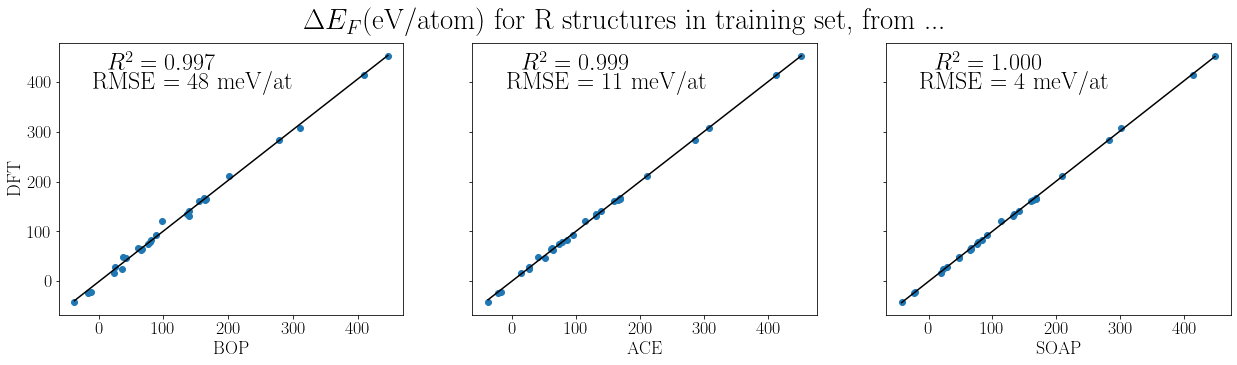

In [84]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label ={'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP' }
phase_pos = {'R': 0}#, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*len(featurename_pos), plt.rcParams['figure.figsize'][1]), sharey = True)
for (featuregroup, I), axes in zip(featurename_pos.items(), axes):
    test_split_samples = BS.index.intersection(BS_predict['R'].index)
    targetname = f'{target_case}__{featuregroup}'
    x = Prediction_Values[(featuregroup, 'R')][targetname][test_split_samples]*1000
    y = BS.loc[test_split_samples][target_case]*1000
    reg = np.polyfit(x, y, 1)
    pol = np.poly1d(reg)
    r2 = r2_score(y, pol(x))
    rmse = mean_squared_error(y, pol(x))
    axes.scatter(x, y) 
    axes.plot([x.min(), x.max()], pol([x.min(), x.max()]), 'k')
    axes.annotate (rf'$R^2 = {r2:.3f}$\newline RMSE = {rmse:.0f} meV/at', (0.1, 0.9), xycoords='axes fraction')
    axes.set_xlabel(featurename_label[featuregroup])
axes[0].set_ylabel('DFT')
fig.suptitle(r'$\Delta E_F $(eV/atom) for R structures in training set, from ...')
fig.savefig('Fe-Mo/graphs/Rstructs_Prediction_Vs_DFT.pdf')

In [85]:
BS_predict['P'][BS_predict['P']['Fe_pv'] == 0]

,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,nelem,Structure
Mo_sv56.P-BBBBBBBBBBBB.NM,56,0.0,56.0,0.0,1.0,0,1,11


In [86]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'R_old'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'R_old'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'R_old'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

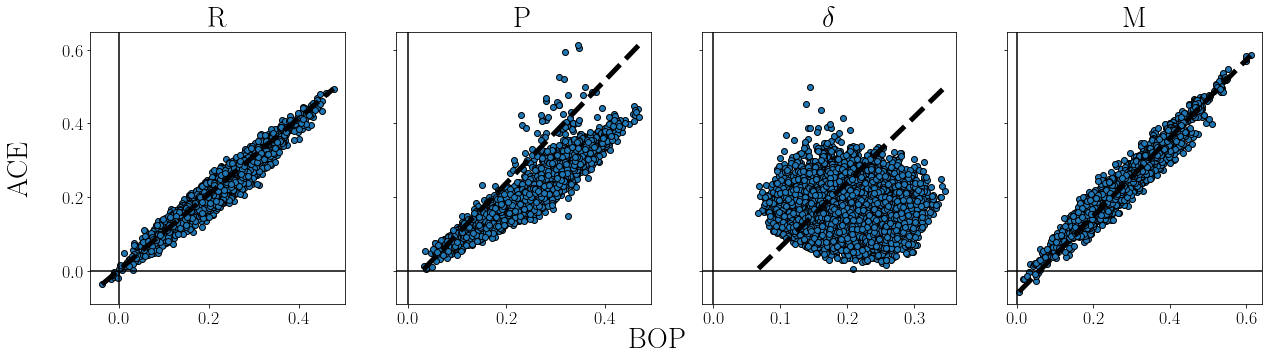

In [87]:
#featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1}
phase_pos = {'R': 0, 'P': 2, 'delta': 3, 'M': 4}#, 'R_old': 1}
phase_label = {'R': 'R', 'P': 'P', 'delta': r'$\delta$', 'M': 'M'}
bopmodel = '0.7dprojections_0.5os'
acemodel = 'ACE'
fig, axes = plt.subplots(
    1, len(phase_pos),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]),
    sharey=True)
for phase, axes  in zip(phase_pos, axes):
    if phase == 'R_old':
        continue
    intersection = Prediction_Values[(bopmodel, phase)].index.intersection(Prediction_Values[(acemodel, phase)].index)
    x = Prediction_Values[(bopmodel, phase)][target_case+'__'+bopmodel][intersection]
    y = Prediction_Values[(acemodel, phase)][target_case+'__'+acemodel].loc[intersection]
    axes.scatter(x,y,edgecolor='k')
    axes.plot([x.min(), x.max()], [y.min(), y.max()], '--k', lw=5)
    axes.set_title(phase_label[phase])
    axes.axhline(c='k')
    axes.axvline(c='k')

fig.supxlabel('BOP', y=-0.01)
fig.supylabel(acemodel, x=0.07)
fig.savefig('Fe-Mo/graphs/Fe-Mo-PredictionDifferences.pdf')

# predicted vs DFT

# Predicted convex hulls 

In [88]:
for (model, phase), prediction_values in Prediction_Values.items() :
    if (target_case, model) not in BS_predict[phase].columns:
        BS_predict[phase] = pd.concat([BS_predict[phase], prediction_values], axis = 1)

In [89]:
BS_predict.keys()#['R'].filter(regex=target_case)

dict_keys(['R', 'R_old', 'P', 'delta', 'M'])

In [90]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls

In [91]:
from scipy.spatial import ConvexHull

In [103]:
phasesloc= {'R':0, 'M': 1,'P':2 ,'delta':3}
targetsloc = {target_name: i for i, target_name in enumerate(BS_predict['R'].filter(regex='EF_nmhcp').columns)}

In [104]:
phasesloc

{'R': 0, 'M': 1, 'P': 2, 'delta': 3}

In [105]:
targetsloc

{'EF_nmhcp__0.7dprojections_0.5os': 0,
 'EF_nmhcp__ACE': 1,
 'EF_nmhcp__SOAP_specific_small': 2}

In [106]:
from matplotlib.lines import Line2D

In [107]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'R_old'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'R_old'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'R_old'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

In [108]:
feature_labels = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP'}

In [109]:
phase_labels = {'delta': r'$\delta$', 'R': 'R', 'M': 'M', 'P': 'P'}

In [110]:
phasesloc

{'R': 0, 'M': 1, 'P': 2, 'delta': 3}

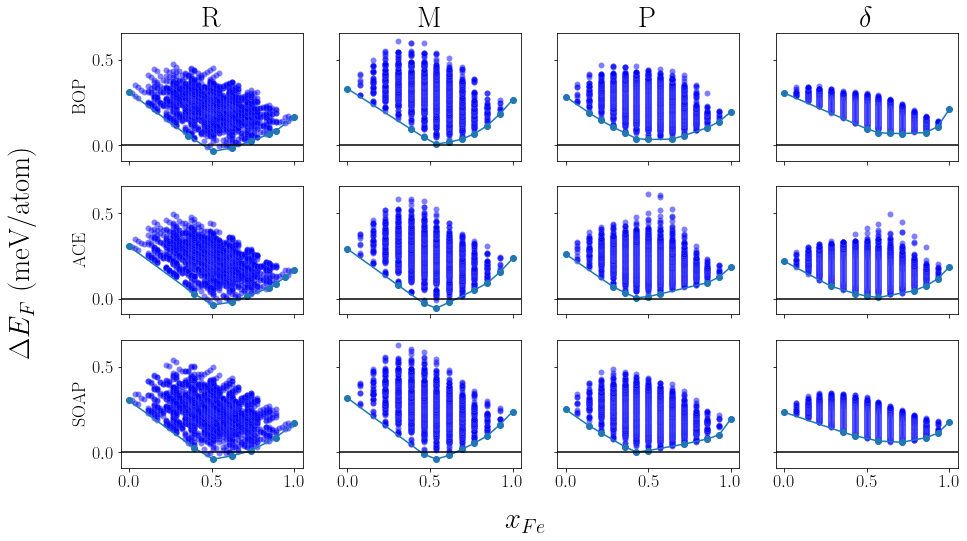

In [115]:
P = Plotting()
inchull = {}
opo_chull = {}
CHULLS = {}
fig, axes = plt.subplots(len(targetsloc), len(phasesloc), sharey = True, sharex=True, figsize =(15,8))
for target_name, J in targetsloc.items(): #(target_name, targetvalues), ax in zip(bspredict.filter(regex=target_case).items(), axes):
    if 'R_old' in phase:
        continue
#    if 'P' not in phase:
#        continue
#    fig, axes = plt.subplots(1,2, sharey=True)
    labels = []
    handles = []
    CHULLS[target_name]={}
    featurename = target_name.replace(target_case+'__', '')
    axes[J, 0].set_ylabel(feature_labels[featurename])
    for phase, I in phasesloc.items(): # phase, bspredict in BS_predict.items():
        axes[0,I].set_title(phase_labels[phase])
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name ])
        axes[J,I].scatter(plottable['Fe_pv'].values, plottable[target_name].values, c='b', edgecolor = 'w', lw=0.1, alpha=0.5 )
        chull_xy = pd.DataFrame([])
        chull = P.get_convex_hulls(
            {phase: plottable }, ['Fe_pv'], getproperty=target_name, viewpoint=(0.0,-10 )
        )
        CHULLS[target_name].update(chull)
        all_vertices_low = np.unique(np.hstack(chull[phase].simplices[chull[phase].good]))
        all_vertices_high= np.unique(np.hstack(chull[phase].simplices[~chull[phase].good]))
        inchull[(phase, target_name)] = plottable.iloc[all_vertices_low].sort_values(by='Fe_pv')
        opo_chull[(phase, target_name)] = plottable.iloc[all_vertices_high].sort_values(by='Fe_pv')
        l = axes[J,I].plot(inchull[(phase, target_name)]['Fe_pv'].values, inchull[(phase, target_name)][target_name].values, 'o-', label = 'chull')
        labels.append(target_name)
        handles.append(l[0])
#        axes[J,I].plot(opo_chull[(phase, target_name)]['Fe_pv'].values, opo_chull[(phase, target_name)][target_name].values, 'o-', c=l[0].get_color(), label = target_name)
#        axes[J,I].plot(opo_chull[(phase, target_name)]['Fe_pv'].values, opo_chull[(phase, target_name)][target_name].values, 'o-', c='r', label = 'opo_chull')
        axes[J,I].axhline(c='k')
#        ax.legend(handles, labels)
handles = [
    Line2D([0], [0], marker = 'o', markerfacecolor='k'),
    Line2D([0], [0], marker = 'o', linestyle='-', color='b',  markerfacecolor='b', markeredgecolor='b'),
    Line2D([0], [0], marker = 'o', markerfacecolor='r', linestyle='-', color='r'),
]
fig.supylabel(r'$\Delta E_F$ (meV/atom)')#target_name)
labels = ['predictions', 'chull', 'oppo_chull']
fig.supxlabel('$x_{Fe}$')
#fig.legend(handles, labels, bbox_to_anchor=(1.1, 1))
fig.savefig('Fe-Mo/graphs/compare_predictions.pdf')

In [ ]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'R_old'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'R_old'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'R_old'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

In [112]:
test_errors.keys()

dict_keys(['0.7dprojections_0.5os', 'ACE'])

In [144]:
index1 = Prediction_Values[(featuregroup, phase)].index

In [145]:
index2 = BS_predict[phase]['Fe_pv'].index

In [149]:
len(index1)

4095

In [150]:
len(index2)

4096

In [148]:
index2.symmetric_difference(index1)

Index(['Fe_pv24Mo_sv32.P-BABABBAABBBA.NM'], dtype='object')

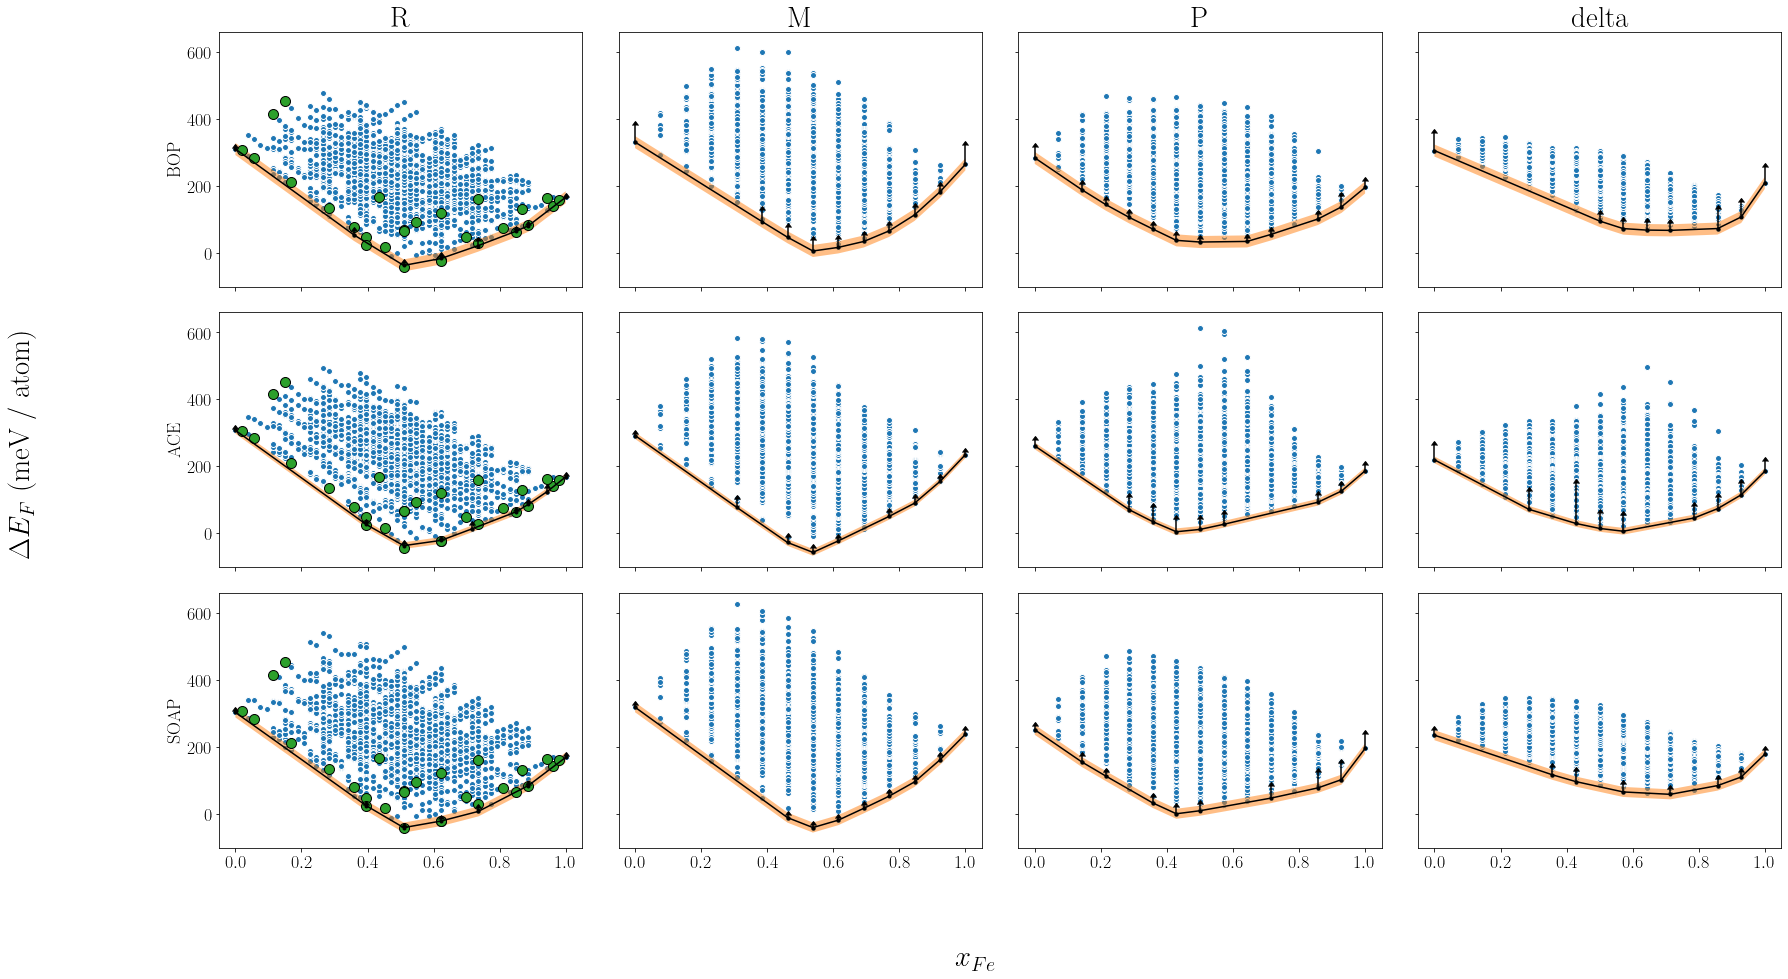

In [202]:
featurename_pos = {'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP_specific_small': 0.015}#?
phase_pos = {'R': 0, 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
#fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1]), sharey = True)
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols,plt.rcParams['figure.figsize'][1]*nrows),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes[I,J].scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes[I,J].plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes[I,J].fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes[I,J].errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
        axes[I,J].scatter(
            BS['Fe_pv'][training_samples],
            BS[target_case][training_samples]*1000,
            edgecolor='k',
            label='DFT calculations',
            s = 100
            )
        axes[0, J].set_title(phase)
#    axes[0,I].legend( fontsize=plt.rcParams['font.size']*0.6,bbox_to_anchor = (1, 1),)
    axes[I,0].set_ylabel(featurename_label[featuregroup])
fig.supxlabel('$x_{Fe}$')
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.supylabel(r'$\Delta E_F$ (meV / atom)')
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')
#fig.supxlabel('$x_{Fe}$', y=-0.01)
#fig.supylabel (r'$\Delta E_F$ (meV / atom)')
#fig.legend([Line2D([0],[0], ))])

In [115]:
BOP_vs_ACE = (Prediction_Values[(bopmodel, 'R')][f'{target_case}__{bopmodel}'] - Prediction_Values[(acemodel, 'R')][f'{target_case}__{acemodel}']).abs()

## difference as function to distance to the hull

In [116]:
from scipy.spatial import Delaunay

In [117]:
xp = inchull[('R',f'{target_case}__{acemodel}')]['Fe_pv']
yp = inchull[('R',f'{target_case}__{acemodel}')][f'{target_case}__{acemodel}']

In [118]:
import pdb

In [119]:
def distance_to_chull(x, y,  chull_def: pd.core.series.Series, valuename : str):
    y_in_chull = np.interp(x, xp, yp,)
    return y - y_in_chull

In [125]:
targetname=f'{target_case}__ACE'
distance_to_chull(BS_predict['R']['Fe_pv']['Fe_pv53.R.NM'], Prediction_Values[(acemodel, 'R')][targetname]['Fe_pv53.R.NM'], inchull[('R',f'{target_case}__{acemodel}')], f'{target_case}__{acemodel}' )

0.0

In [126]:
xy = pd.concat([BS_predict['R']['Fe_pv'], Prediction_Values[(acemodel, 'R')][targetname]], axis = 1)

In [127]:
distances_to_chull = pd.Series([], name = 'DistanceToChull')
for index, compound in xy.iterrows():
    distances_to_chull[index] = distance_to_chull(compound['Fe_pv'], compound[targetname], inchull[('R', f'{target_case}__{acemodel}')], targetname)

In [128]:
selection = xy.index.str.contains('NM')

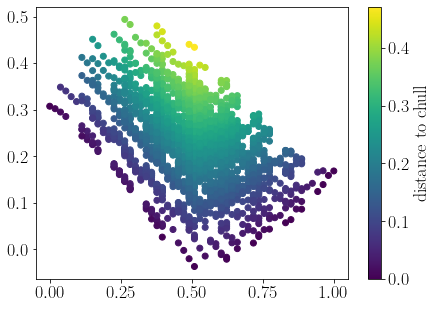

In [129]:
plt.scatter(xy['Fe_pv'][selection], xy[targetname][selection], c=distances_to_chull[selection])
plt.colorbar(label='distance to chull')

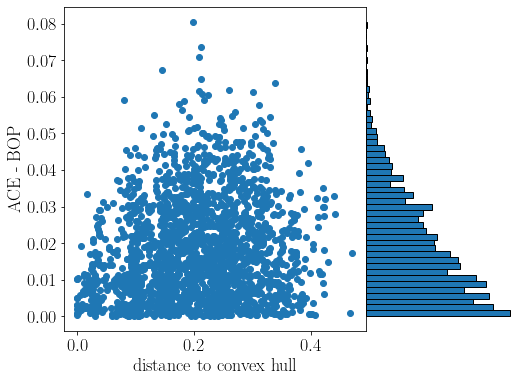

In [131]:
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.6, 0.9])
ax2 = fig.add_axes([0.7, 0.1, 0.3,0.9], sharey = axes)
ax2.set_axis_off()
axes.scatter(distances_to_chull[selection], BOP_vs_ACE[selection])
hist = ax2.hist(BOP_vs_ACE[selection], orientation='horizontal', bins = 50,edgecolor='k')
axes.set_xlabel ('distance to convex hull')
axes.set_ylabel('ACE - BOP')
fig.savefig(f'{dataset}/graphs/{dataset}_error_vs_distance_to_chull.pdf')

Text(0.5, 1.0, 'Kernel Ridge / EF_nmhcp__ACE')

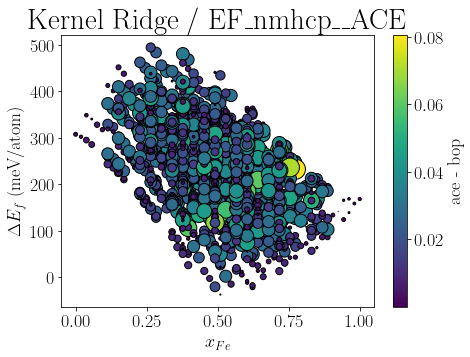

In [132]:
fig, axes = plt.subplots()
mapble = axes.scatter(xy['Fe_pv'], xy[targetname]*1000, c=BOP_vs_ACE, s=BOP_vs_ACE*5000, edgecolor='k')#c=distances_to_chull)
plt.colorbar(label='ace - bop', mappable=mapble)
axes.set_xlabel(r'$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_f$ (meV/atom)')
axes.set_title(ModelName+' / '+targetname)

In [133]:
Phases = {'R':'R', 'delta': r'$\delta$', 'P': 'P', 'M':'M'}

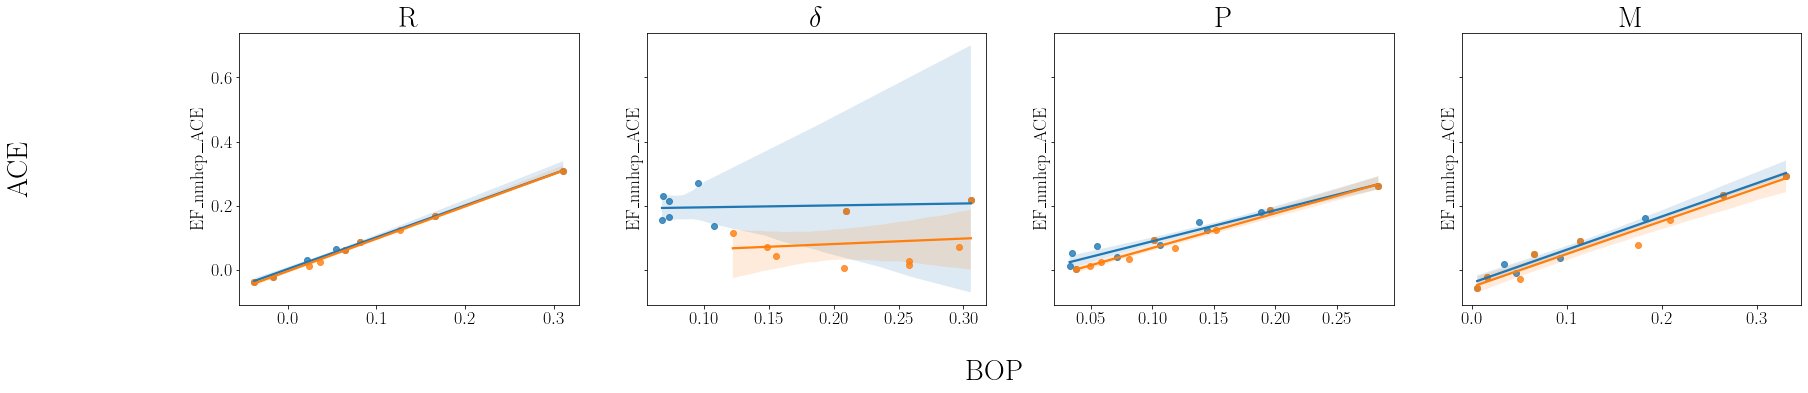

In [134]:
fig, axes = plt.subplots(1, len(Phases), sharey=True, figsize=(plt.rcParams['figure.figsize'][0]*len(Phases), plt.rcParams['figure.figsize'][1]))
for (phase, title), axes  in zip(Phases.items(), axes):
    inchull_bop = inchull[(phase, 'EF_nmhcp__0.7dprojections_0.5os')].index
    inchull_ace = inchull[(phase, 'EF_nmhcp__ACE')].index
    sbop, pbop = pearsonr(Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop], Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_bop])
    sace, pace = pearsonr(Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_ace])
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop]
        , y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_bop], label = f'BOP, $R^2 = {sbop:.3f}$',
        ax=axes
    )
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], 
        y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_ace], label = f'ACE, $R^2 = {sace:.3f}$', ax = axes, 
    )
    axes.set_xlabel('')
    axes.set_title(title)
fig.supxlabel ('BOP', y=-0.1)
fig.supylabel ('ACE', x=0.01)
plt.savefig(f'{dataset}/graphs/samples_in_convex_hull.pdf')

# Recover samples in convex hull for validation 

In [135]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [136]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)

In [137]:
for (phase, target_name), inchullist in opo_chull.items():
    group_loc = os.path.join(ValidationDataLocation, 'opochull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)


In [138]:
inchull[('R','EF_nmhcp__0.7dprojections_0.5os' )].shape

(8, 3)

In [139]:
    AtomsObjects[phase]['atoms'][inchullist.index]

Mo_sv52.M-BBBBBBBBBBB.NM           (Atom('Mo', [0.687132056460881, 1.275763155206...
Fe_pv4Mo_sv48.M-BBBBBBBBBAB.NM     (Atom('Mo', [0.682491389302961, 1.267147064427...
Fe_pv8Mo_sv44.M-BBBBBBBBAAB.NM     (Atom('Mo', [0.6777867396928076, 1.25841218068...
Fe_pv16Mo_sv36.M-BBBBBBBAAAA.NM    (Atom('Mo', [0.6681763553306703, 1.24056906863...
Fe_pv20Mo_sv32.M-BBBBBBAAAAA.NM    (Atom('Mo', [0.6632657172807414, 1.23145173662...
Fe_pv24Mo_sv28.M-BBBBBAAAAAA.NM    (Atom('Mo', [0.6582812681260509, 1.22219736328...
Fe_pv28Mo_sv24.M-ABBBBAAAAAA.NM    (Atom('Fe', [0.6532201701111321, 1.21280067991...
Fe_pv52.M-AAAAAAAAAAA.NM           (Atom('Fe', [0.6210603654963448, 1.15309120569...
Name: atoms, dtype: object

In [140]:
AtomsObjects[phase]['atoms'][opo_chull[(phase, target_name)].index]

Mo_sv52.M-BBBBBBBBBBB.NM           (Atom('Mo', [0.687132056460881, 1.275763155206...
Fe_pv4Mo_sv48.M-BBBBBBBBBAB.NM     (Atom('Mo', [0.682491389302961, 1.267147064427...
Fe_pv8Mo_sv44.M-BBBBBBBBAAB.NM     (Atom('Mo', [0.6777867396928076, 1.25841218068...
Fe_pv16Mo_sv36.M-BBBBBBBAAAA.NM    (Atom('Mo', [0.6681763553306703, 1.24056906863...
Fe_pv20Mo_sv32.M-BBBBBBAAAAA.NM    (Atom('Mo', [0.6632657172807414, 1.23145173662...
Fe_pv24Mo_sv28.M-BBBBBAAAAAA.NM    (Atom('Mo', [0.6582812681260509, 1.22219736328...
Fe_pv28Mo_sv24.M-ABBBBAAAAAA.NM    (Atom('Fe', [0.6532201701111321, 1.21280067991...
Fe_pv52.M-AAAAAAAAAAA.NM           (Atom('Fe', [0.6210603654963448, 1.15309120569...
Name: atoms, dtype: object